# 특성 공학(feature engineering)
- 기존 특성을 이용해서 새로운 특성을 만들어내는 작업
- ex) x, x2, x3

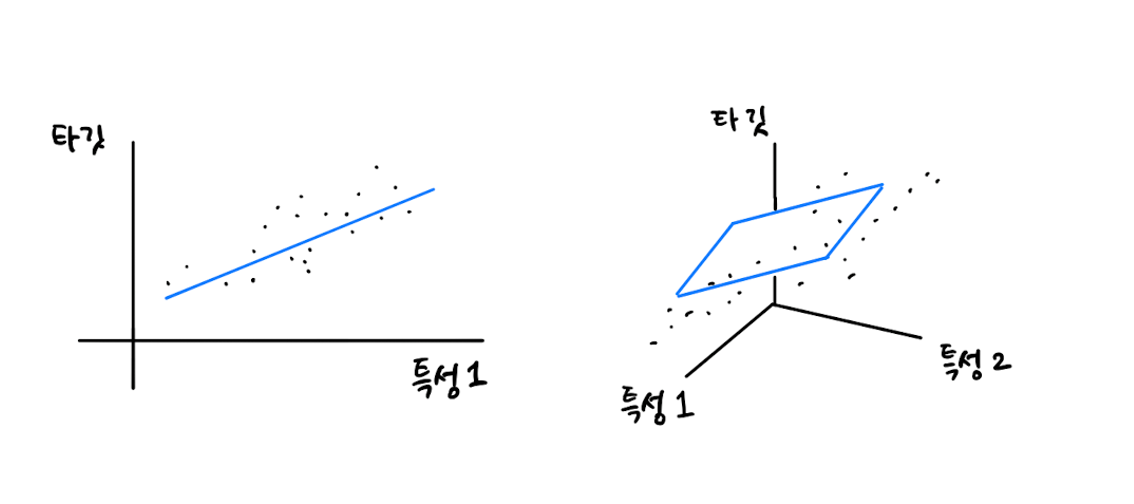

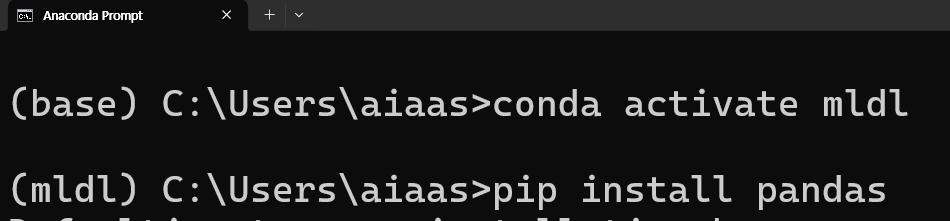

In [11]:
# Linux 명령 실행
# !pip install pandas

In [12]:
import pandas as pd

df = pd.read_csv('perch_full.csv')
df

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94
5,18.0,5.22,3.32
6,18.7,5.20,3.12
7,19.0,5.64,3.05
8,19.6,5.14,3.04
9,20.0,5.08,2.77


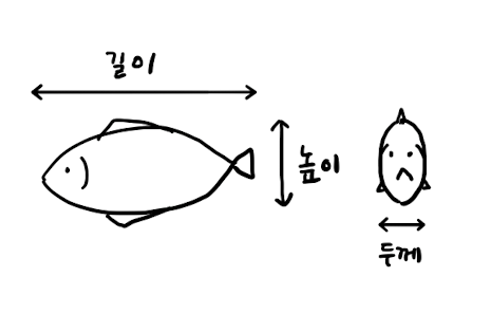

In [13]:
perch_full = df.to_numpy()
print(perch_full)

[[ 8.4   2.11  1.41]
 [13.7   3.53  2.  ]
 [15.    3.82  2.43]
 [16.2   4.59  2.63]
 [17.4   4.59  2.94]
 [18.    5.22  3.32]
 [18.7   5.2   3.12]
 [19.    5.64  3.05]
 [19.6   5.14  3.04]
 [20.    5.08  2.77]
 [21.    5.69  3.56]
 [21.    5.92  3.31]
 [21.    5.69  3.67]
 [21.3   6.38  3.53]
 [22.    6.11  3.41]
 [22.    5.64  3.52]
 [22.    6.11  3.52]
 [22.    5.88  3.52]
 [22.    5.52  4.  ]
 [22.5   5.86  3.62]
 [22.5   6.79  3.62]
 [22.7   5.95  3.63]
 [23.    5.22  3.63]
 [23.5   6.28  3.72]
 [24.    7.29  3.72]
 [24.    6.38  3.82]
 [24.6   6.73  4.17]
 [25.    6.44  3.68]
 [25.6   6.56  4.24]
 [26.5   7.17  4.14]
 [27.3   8.32  5.14]
 [27.5   7.17  4.34]
 [27.5   7.05  4.34]
 [27.5   7.28  4.57]
 [28.    7.82  4.2 ]
 [28.7   7.59  4.64]
 [30.    7.62  4.77]
 [32.8  10.03  6.02]
 [34.5  10.26  6.39]
 [35.   11.49  7.8 ]
 [36.5  10.88  6.86]
 [36.   10.61  6.74]
 [37.   10.84  6.26]
 [37.   10.57  6.37]
 [39.   11.14  7.49]
 [39.   11.14  6.  ]
 [39.   12.43  7.35]
 [40.   11.93

In [14]:
import numpy as np

perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

print(perch_weight)

[   5.9   32.    40.    51.5   70.   100.    78.    80.    85.    85.
  110.   115.   125.   130.   120.   120.   130.   135.   110.   130.
  150.   145.   150.   170.   225.   145.   188.   180.   197.   218.
  300.   260.   265.   250.   250.   300.   320.   514.   556.   840.
  685.   700.   700.   690.   900.   650.   820.   850.   900.  1015.
  820.  1100.  1000.  1100.  1000.  1000. ]


In [15]:
# 훈련 세트와 테스트 세트로 나눠준다
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(perch_full, perch_weight, random_state=42)

print(train_input.shape)
print(test_input.shape)
print(train_target.shape)
print(test_target.shape)

(42, 3)
(14, 3)
(42,)
(14,)


# 3개 기본 속성을 여러 개의 속성으로 만들어준다
- 과소 적합 방지
- 모델의 복잡도를 높이기 위해

In [16]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures()
poly.fit([[2, 3]])              # 2, 3 기본 속성 학습
print(poly.transform([[2, 3]])) # 2, 3 기본 속성을 다수의 속성으로 변환
print(poly.get_feature_names())

[[1. 2. 3. 4. 6. 9.]]
['1', 'x0', 'x1', 'x0^2', 'x0 x1', 'x1^2']


# 1 bias 자동 절편 추가
# 2, 3
# 4 = 2**2
# 6 = 2*2
# 9 = 3**2

In [18]:
# train_input에 특성 공학 적용
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
print(train_poly.shape)   # 기본 속성 3개 -> 9개 속성 확장
print(poly.get_feature_names())
print(train_poly)

(42, 9)
['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2', 'x2^2']
[[  19.6       5.14      3.04    384.16    100.744    59.584    26.4196
    15.6256    9.2416]
 [  22.        5.88      3.52    484.      129.36     77.44     34.5744
    20.6976   12.3904]
 [  18.7       5.2       3.12    349.69     97.24     58.344    27.04
    16.224     9.7344]
 [  17.4       4.59      2.94    302.76     79.866    51.156    21.0681
    13.4946    8.6436]
 [  36.       10.61      6.74   1296.      381.96    242.64    112.5721
    71.5114   45.4276]
 [  25.        6.44      3.68    625.      161.       92.       41.4736
    23.6992   13.5424]
 [  40.       11.93      7.11   1600.      477.2     284.4     142.3249
    84.8223   50.5521]
 [  39.       12.43      7.35   1521.      484.77    286.65    154.5049
    91.3605   54.0225]
 [  43.       11.93      7.28   1849.      512.99    313.04    142.3249
    86.8504   52.9984]
 [  22.        5.64      3.52    484.      124.08     77.44     31.80

## 다중 회귀 모델 훈련

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))

0.9903183436982124


In [ ]:
print(lr.score(train_poly, train_target))

In [20]:
# test_input 데이터도 3개 -> 9개 특성 공학 적용
test_poly = poly.transform(test_input)

In [21]:
print(lr.score(test_poly, test_target))

0.9714559911594078


## 훈련 데이터 점수(0.9903183436982124) > 테스트 데이터 점수(0.9714559911594078)
- 과소 적합이 발생하지 않는 것을 확인할 수 있다

In [22]:
# 특성을 더 많이 확장할 수도 있다
poly = PolynomialFeatures(degree=5, include_bias=False)     # 5제곱까지 범위를 늘려라
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)
print(train_poly.shape)                                     # 3개 속성 -> 55개 속성으로 확장

(42, 55)


In [23]:
# 55개 속성으로 학습 진행
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.999999999999586
-144.405781301649


## Overfitting이 발생함
 - 지나치게 훈련 데이터에 과적합이 생겼다
 - 테스트 점수가 아주 낮다
 - 범용적인 예측기로 사용할 수 없다

## 과적합(Overfitting)이 발생했을 때는 
- 특성 공학의 degree를 줄일 필요가 있다
- Regularization(정규화, 규제)

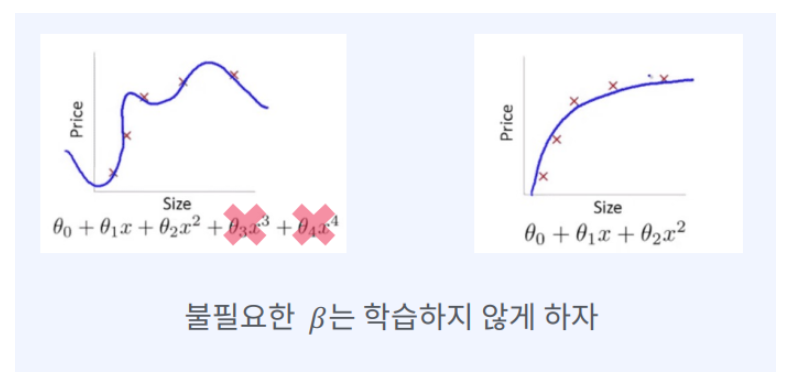

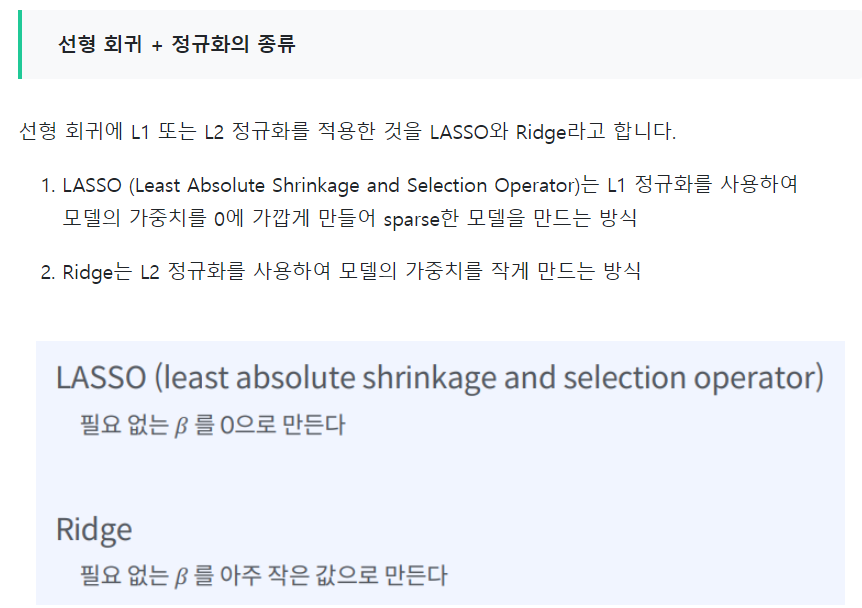

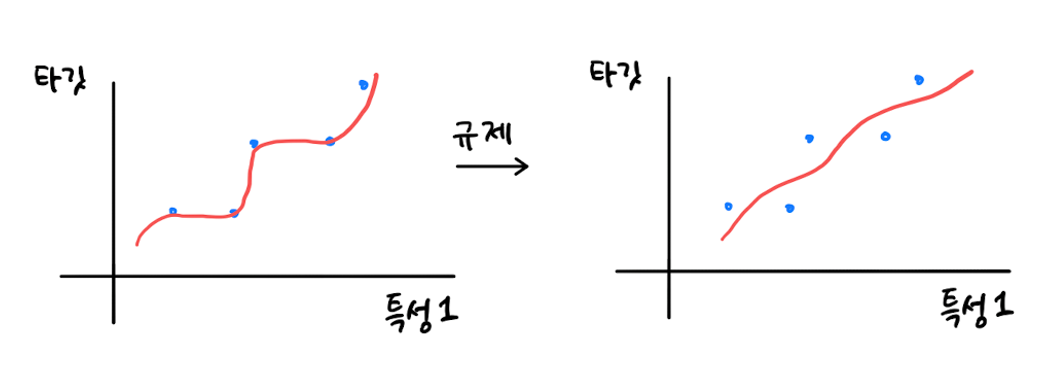

In [26]:
# 특성을 평균, 표준편차를 이용해 표준점수를 변경하는 작업을 진행

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

In [27]:
# 릿지 회귀
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))

0.9896101671037343


In [28]:
print(ridge.score(test_scaled, test_target))

0.9790693977615392


## 규제를 적용해서 적정한 학습이 이루어진 것을 확인할 수 있다

In [29]:
# alpha값을 변화시켜서 최적의 규제 강도를 정하기 위한 실험
train_score = []
test_score = []

# alpha값이 작으면 기울기를 적게 완화하고(규제 강도가 상대적으로 약하다)
# alpha값이 크면 기울기를 크게 줄인다(규제 강도가 세진다)
# hyperparameter 실험을 통해서 최적의 값을 찾아야 한다
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    ridge = Ridge(alpha = alpha)
    ridge.fit(train_scaled, train_target)
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))


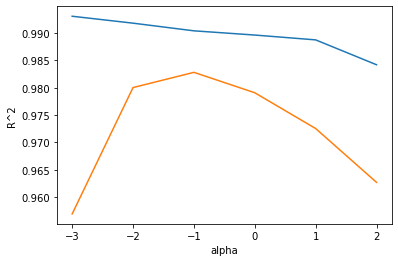

In [32]:
# 시각화
import matplotlib.pyplot as plt

# plt.plot(alpha_list, train_score)
# plt.plot(alpha_list, test_score)
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

## 적절한 alpha값은 두 그래프의 차이가 가장 적고, 테스트 점수가 가장 높은
## -1, 즉, alpha=0.1일 때이다

In [33]:
ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9903815817570365
0.9827976465386867


In [35]:
# 라쏘 모델 적용
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))

0.9897898972080961


In [36]:
print(lasso.score(test_scaled, test_target))

0.9800593698421884


In [40]:
# 라쏘 모델의 최적 alpha값 찾기
# alpha값을 변화시켜서 최적의 규제 강도를 정하기 위한 실험
train_score = []
test_score = []

# alpha값이 작으면 기울기를 적게 완화하고(규제 강도가 상대적으로 약하다)
# alpha값이 크면 기울기를 크게 줄인다(규제 강도가 세진다)
# hyperparameter 실험을 통해서 최적의 값을 찾아야 한다
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    # Lasso모델은 최적의 alpha값을 찾기 위해 반복을 하는데 지정한 반복횟수가 부족하면
    # 경고가 발생한다
    lasso = Lasso(alpha = alpha, max_iter=1000)
    lasso.fit(train_scaled, train_target)
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

c:\ProgramData\anaconda3\envs\mldl\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 23364.07596993995, tolerance: 518.2793833333334
  positive)
c:\ProgramData\anaconda3\envs\mldl\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 20251.975097475763, tolerance: 518.2793833333334
  positive)
c:\ProgramData\anaconda3\envs\mldl\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 806.2370926330841, tolerance: 518.2793833333334
  positive)


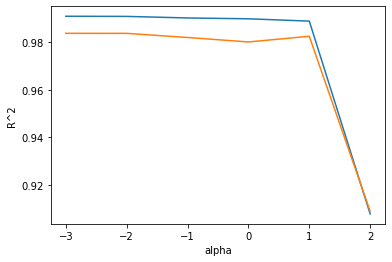

In [41]:
# 시각화
import matplotlib.pyplot as plt

# plt.plot(alpha_list, train_score)
# plt.plot(alpha_list, test_score)
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

# 

## -3은 10^-3 = 0.001
## -2는 10^-2 = 0.01
## 1은 10^1 = 10

In [45]:
lasso = Lasso(alpha=0.001)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.990856843502147
0.9836870822242811


c:\ProgramData\anaconda3\envs\mldl\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 23364.07596993995, tolerance: 518.2793833333334
  positive)


In [46]:
# Lasso는 중요하지 않는 특성을 0으로 만든다
# 0인 특성의 갯수는
print(np.sum(lasso.coef_ == 0))

0


## 현재는 모든 속성을 사용했다